# Notebook #3 — Porównanie metod klasteryzacji segmentów PMSM

Porównujemy **4 podejścia** do klasteryzacji segmentów z NB#2:
1. **KMeans** — feature-based,
2. **GMM** — feature-based / probabilistyczny,
3. **HDBSCAN** — feature-based / density-based,
4. **k-Medoids + multivariate DTW** — trajectory-based.

**Cel:** nie „najwyższa pojedyncza metryka", lecz która metoda daje grupy **spójne, stabilne, interpretowalne fizycznie i użyteczne do cluster-aware augmentation**. Ostateczny arbiter (wpływ na regresję `pm`) nastąpi dopiero po augmentacji (NB#5).

**Zasady:** brak `pm`/temperatur na wejściu; podział po `profile_id`; skalowanie i dobór parametrów **wyłącznie na TRAIN**; segmentacja z NB#2 pozostaje nietknięta; `random_state=42`.

In [1]:
import json, time, warnings, platform
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             normalized_mutual_info_score)
warnings.filterwarnings("ignore")

RANDOM_STATE=42
RNG=np.random.default_rng(RANDOM_STATE)
OUT=Path("regime_discovery_outputs")
NB3=Path("clustering_outputs"); (NB3/"figures").mkdir(parents=True, exist_ok=True)
RAW_PATH="./dataset/raw/measures_v2.csv"
DRIVERS=["motor_speed","torque","i_d","i_q","u_d","u_q"]
K_RANGE=range(2,11)
STABILITY_REPS=20
STABILITY_FRAC=0.85
DTW_RADIUS=8            # Sakoe-Chiba (dla L=128)
RUNTIMES={}            # fit/assign/prep czasy

# zaleznosci opcjonalne
try:
    import hdbscan; HAS_HDBSCAN=True
except Exception: HAS_HDBSCAN=False
try:
    from tslearn.metrics import cdist_dtw; HAS_TSLEARN=True
except Exception: HAS_TSLEARN=False
print("hdbscan:",HAS_HDBSCAN," tslearn(DTW):",HAS_TSLEARN)
print("Uwaga: scikit-learn-extra niedostepny -> k-Medoids jako wlasny PAM na macierzy DTW (fallback).")

hdbscan: True  tslearn(DTW): True
Uwaga: scikit-learn-extra niedostepny -> k-Medoids jako wlasny PAM na macierzy DTW (fallback).


## 1. Audyt artefaktów NB#2
Sprawdzamy strukturę, podział train/test po `profile_id` i brak zmiennych leakage. **Nie zmieniamy granic segmentów.**

In [2]:
seg=pd.read_csv(OUT/"segments_features.csv")
idx=pd.read_csv(OUT/"segments_series_index.csv")
cfg=json.load(open(OUT/"segmentation_config.json"))
assert (seg["segment_id"].values==idx["segment_id"].values).all(), "Niespojnosc kolejnosci segmentow!"

print(f"Segmentow: {len(seg)} | profili: {seg.profile_id.nunique()}")
print(f"TRAIN: {int(seg.in_train.sum())} segm / {seg.loc[seg.in_train,'profile_id'].nunique()} profili")
print(f"TEST : {int((~seg.in_train).sum())} segm / {seg.loc[~seg.in_train,'profile_id'].nunique()} profili")
ov=set(seg.loc[seg.in_train,'profile_id'])&set(seg.loc[~seg.in_train,'profile_id'])
print("Nakladanie profile_id train/test:", ov if ov else "BRAK (OK)")
leak=[c for c in seg.columns if any(k in c for k in ['pm','stator'])]
print("Kolumny leakage w wejsciu:", leak if leak else "BRAK (OK)")
print("duration_s: min=%.0f med=%.0f max=%.0f q90=%.0f"%(seg.duration_s.min(),seg.duration_s.median(),seg.duration_s.max(),seg.duration_s.quantile(.9)))
TRAIN=seg.in_train.values; TEST=~TRAIN
print("\nUwaga metodyczna: zapisany segments_features.csv ma zredukowany zestaw cech;")
print("pelny zestaw (mean/std/median/IQR/min/max/slope) przeliczamy ponizej z surowych danych,")
print("uzywajac NIEZMIENIONYCH granic segmentow (start_sample/end_sample).")

Segmentow: 1118 | profili: 69
TRAIN: 734 segm / 47 profili
TEST : 384 segm / 22 profili
Nakladanie profile_id train/test: BRAK (OK)
Kolumny leakage w wejsciu: BRAK (OK)
duration_s: min=120 med=260 max=12190 q90=1162

Uwaga metodyczna: zapisany segments_features.csv ma zredukowany zestaw cech;
pelny zestaw (mean/std/median/IQR/min/max/slope) przeliczamy ponizej z surowych danych,
uzywajac NIEZMIENIONYCH granic segmentow (start_sample/end_sample).


## 2. Reprezentacja feature-based (pełny zestaw, przeliczony z surowych danych)
Dla każdego driver'a: **mean, std, median, IQR, min, max, slope** + **duration**. Granice segmentów pochodzą z NB#2 (`start_sample`/`end_sample`) — segmentacja pozostaje niezależna od klasteryzacji.

In [3]:
t0=time.time()
raw=pd.read_csv(RAW_PATH)
raw["_idx"]=raw.groupby("profile_id").cumcount()
prof_arr={pid:g[DRIVERS].to_numpy(np.float64) for pid,g in raw.groupby("profile_id")}
def seg_feats(a):
    q1=np.percentile(a,25,axis=0); q3=np.percentile(a,75,axis=0)
    x=np.arange(len(a))
    slope=np.polyfit(x,a,1)[0] if len(a)>1 else np.zeros(a.shape[1])
    return dict(mean=a.mean(0),std=a.std(0),median=np.median(a,0),iqr=q3-q1,
                mn=a.min(0),mx=a.max(0),slope=slope)
rows=[]
for _,r in idx.iterrows():
    a=prof_arr[r.profile_id][int(r.start_sample):int(r.end_sample)]
    f=seg_feats(a); d={"segment_id":r.segment_id}
    for j,v in enumerate(DRIVERS):
        d[f"{v}_mean"]=f["mean"][j]; d[f"{v}_std"]=f["std"][j]; d[f"{v}_median"]=f["median"][j]
        d[f"{v}_iqr"]=f["iqr"][j]; d[f"{v}_min"]=f["mn"][j]; d[f"{v}_max"]=f["mx"][j]; d[f"{v}_slope"]=f["slope"][j]
    d["duration_s"]=(int(r.end_sample)-int(r.start_sample))/cfg["series_dims"][0]*0+ (int(r.end_sample)-int(r.start_sample))/2.0
    rows.append(d)
F=pd.DataFrame(rows)
ALL_FEATS=[c for c in F.columns if c!="segment_id"]
print(f"Cechy: {len(ALL_FEATS)} | segmentow: {len(F)} | t={time.time()-t0:.1f}s")
F.head(3)

Cechy: 43 | segmentow: 1118 | t=2.9s


,segment_id,motor_speed_mean,motor_speed_std,motor_speed_median,motor_speed_iqr,motor_speed_min,motor_speed_max,motor_speed_slope,torque_mean,torque_std,...,u_d_max,u_d_slope,u_q_mean,u_q_std,u_q_median,u_q_iqr,u_q_min,u_q_max,u_q_slope,duration_s
0,2_0,99.997200,0.029632,99.998436,0.036440,99.572021,100.552002,-7.792670e-07,206.027225,11.599565,...,1.368377,-0.000048,8.717342,0.248747,8.757797,0.038450,4.232886,8.798512,0.000031,3710.0
1,2_1,100.002092,0.023655,99.999863,0.030586,99.422050,100.060387,-2.195975e-06,0.281256,1.812389,...,1.701082,-0.000002,4.139844,0.080529,4.150350,0.043581,3.919605,8.007488,0.000009,5968.5
2,3_2,100.000960,0.021944,100.000572,0.030821,99.835388,100.289642,-3.005979e-07,102.885320,8.129025,...,1.446143,-0.000030,7.646024,0.270920,7.667285,0.012432,4.125928,7.685420,0.000012,4825.0


## 3. Czyszczenie cech i skalowanie (decyzje wyłącznie na TRAIN)
1. usuwamy cechy near-zero variance (na TRAIN),
2. usuwamy jedną z pary silnie skorelowanych (|r|>0.95, na TRAIN),
3. `StandardScaler` dopasowany **tylko na TRAIN**. Ta sama macierz zasila KMeans/GMM/HDBSCAN.

In [4]:
Xall=F[ALL_FEATS].to_numpy(np.float64)
Xtr=Xall[TRAIN]
# 1) near-zero variance na TRAIN
var=Xtr.var(0); nzv=[ALL_FEATS[i] for i in range(len(ALL_FEATS)) if var[i]<1e-8]
keep=[f for f in ALL_FEATS if f not in nzv]
# 2) korelacje na TRAIN
Ftr=pd.DataFrame(Xtr,columns=ALL_FEATS)[keep]
corr=Ftr.corr().abs()
upper=corr.where(np.triu(np.ones(corr.shape),1).astype(bool))
drop_corr=[c for c in upper.columns if (upper[c]>0.95).any()]
FEATS=[f for f in keep if f not in drop_corr]
print(f"Usunieto NZV: {nzv}")
print(f"Usunieto redundantne (|r|>0.95): {drop_corr}")
print(f"Finalny zestaw: {len(FEATS)} cech")
scaler=StandardScaler().fit(F.loc[TRAIN,FEATS].to_numpy(np.float64))
Xs=scaler.transform(F[FEATS].to_numpy(np.float64)).astype(np.float64)
Xs_tr=Xs[TRAIN]; Xs_te=Xs[TEST]
print("Macierz feature-based:",Xs.shape,"| train:",Xs_tr.shape)

Usunieto NZV: []
Usunieto redundantne (|r|>0.95): ['motor_speed_median', 'torque_median', 'i_d_median', 'i_q_mean', 'i_q_std', 'i_q_median', 'i_q_iqr', 'i_q_min', 'i_q_max', 'i_q_slope', 'u_d_median', 'u_q_median']
Finalny zestaw: 31 cech
Macierz feature-based: (1118, 31) | train: (734, 31)


## 4. Reprezentacja dla DTW (level-preserving) + benchmark kosztu
Używamy `segments_series_level.npy` (drivery skalowane globalnie skalerem TRAIN, poziom zachowany — istotny dla reżimu). Segmenty mają w NB#2 równą długość L=128 (kontrolowany kompromis: DTW na surowej, zmiennej długości do 24k próbek byłoby O(L²) niewykonalne — patrz benchmark). DTW z pasmem Sakoe-Chiba dopuszcza warping mimo równej długości.

In [5]:
assert HAS_TSLEARN, "tslearn wymagany do DTW"
lvl=np.load(OUT/"segments_series_level.npy").astype(np.float32)  # (n,128,6)
S_tr=lvl[TRAIN]; S_te=lvl[TEST]
print("DTW input:",S_tr.shape,"(train)")
# benchmark maly + pelna macierz TRAIN
_=cdist_dtw(S_tr[:5],global_constraint="sakoe_chiba",sakoe_chiba_radius=DTW_RADIUS)  # warmup
t0=time.time()
Dtr=cdist_dtw(S_tr,global_constraint="sakoe_chiba",sakoe_chiba_radius=DTW_RADIUS).astype(np.float32)
RUNTIMES["kmedoids_dtw_prep"]=time.time()-t0
print(f"Macierz DTW train {Dtr.shape} w {RUNTIMES['kmedoids_dtw_prep']:.1f}s (Sakoe-Chiba r={DTW_RADIUS})")
np.save(NB3/"dtw_matrix_train.npy",Dtr)

DTW input: (734, 128, 6) (train)


Macierz DTW train (734, 734) w 11.7s (Sakoe-Chiba r=8)


## 5. Dobór modeli — wyłącznie na TRAIN
Nie wymuszamy wspólnej liczby klastrów. Każda metoda dobiera K/parametry własnymi kryteriami.

### 5.1 KMeans — Silhouette + elbow (inertia)

In [6]:
km_sel=[]
for k in K_RANGE:
    km=KMeans(k,n_init=10,random_state=RANDOM_STATE).fit(Xs_tr)
    km_sel.append({"K":k,"inertia":km.inertia_,"silhouette":silhouette_score(Xs_tr,km.labels_)})
km_sel=pd.DataFrame(km_sel)
K_KM=int(km_sel.loc[km_sel.silhouette.idxmax(),"K"])
print(km_sel.round(3).to_string(index=False)); print("-> K_KMeans =",K_KM)

 K   inertia  silhouette
 2 16525.045       0.253
 3 14550.100       0.220
 4 12990.087       0.215
 5 11943.162       0.212
 6 11185.243       0.195
 7 10627.883       0.185
 8 10151.973       0.190
 9  9719.407       0.175
10  9352.235       0.174
-> K_KMeans = 2


### 5.2 GMM — BIC/AIC + Silhouette + confidence

In [7]:
gmm_sel=[]
for cov in ["full","diag","tied","spherical"]:
    for k in K_RANGE:
        g=GaussianMixture(k,covariance_type=cov,random_state=RANDOM_STATE,n_init=3,max_iter=200).fit(Xs_tr)
        lab=g.predict(Xs_tr); conf=g.predict_proba(Xs_tr).max(1).mean()
        sil=silhouette_score(Xs_tr,lab) if len(set(lab))>1 else np.nan
        gmm_sel.append({"cov":cov,"K":k,"BIC":g.bic(Xs_tr),"AIC":g.aic(Xs_tr),"silhouette":sil,"confidence":conf})
gmm_sel=pd.DataFrame(gmm_sel)
best=gmm_sel.loc[gmm_sel.BIC.idxmin()]
COV_GMM=best["cov"]; K_GMM=int(best["K"])
print(gmm_sel.sort_values("BIC").head(8).round(3).to_string(index=False))
print(f"-> GMM: cov={COV_GMM}, K={K_GMM} (min BIC)")

 cov  K       BIC       AIC  silhouette  confidence
full  3 22341.382 15061.942       0.146       0.999
full  5 23481.008 11345.543       0.178       1.000
full  6 23593.804  9030.325       0.177       0.999
full  8 24584.216  5164.712       0.158       1.000
full  4 24874.495 15167.043       0.196       1.000
full  2 24907.174 20055.747       0.185       0.998
full  7 25344.490  8352.999       0.173       1.000
full 10 26405.799  2130.270       0.148       1.000
-> GMM: cov=full, K=3 (min BIC)


### 5.3 HDBSCAN — analiza wrażliwości (min_cluster_size, min_samples)
Główny wariant: wspólna przestrzeń feature-based. `label=-1` (szum) nie jest traktowany jako klaster w Silhouette/DBCV.

In [8]:
def hdb_metrics(labels):
    m=labels!=-1; n=len(labels)
    ncl=len(set(labels[m])); noise=1-m.mean()
    cov=m.mean()
    return ncl,noise,cov,m
hdb_sel=[]
for mcs in [15,25,40,60]:
    for ms in [None,5,10]:
        cl=hdbscan.HDBSCAN(min_cluster_size=mcs,min_samples=ms,prediction_data=True).fit(Xs_tr)
        ncl,noise,cov,m=hdb_metrics(cl.labels_)
        try: dbcv=hdbscan.validity.validity_index(Xs_tr[m],cl.labels_[m]) if ncl>1 else np.nan
        except Exception: dbcv=np.nan
        hdb_sel.append({"min_cluster_size":mcs,"min_samples":ms,"n_clusters":ncl,
                        "noise_ratio":round(noise,3),"coverage":round(cov,3),"DBCV":round(float(dbcv),3) if dbcv==dbcv else np.nan})
hdb_sel=pd.DataFrame(hdb_sel)
print(hdb_sel.to_string(index=False))
# wybor: max DBCV przy sensownym noise (<0.5) i n_clusters>=2
cand=hdb_sel[(hdb_sel.noise_ratio<0.5)&(hdb_sel.n_clusters>=2)].copy()
best=cand.loc[cand.DBCV.idxmax()] if len(cand) and cand.DBCV.notna().any() else hdb_sel.loc[hdb_sel.n_clusters.idxmax()]
MCS=int(best["min_cluster_size"]); MS=None if pd.isna(best["min_samples"]) else int(best["min_samples"])
print(f"-> HDBSCAN: min_cluster_size={MCS}, min_samples={MS}")

 min_cluster_size  min_samples  n_clusters  noise_ratio  coverage  DBCV
               15          NaN           2        0.685     0.315 0.150
               15          5.0           3        0.644     0.356 0.083
               15         10.0           2        0.680     0.320 0.216
               25          NaN           2        0.606     0.394 0.271
               25          5.0           2        0.586     0.414 0.053
               25         10.0           2        0.680     0.320 0.216
               40          NaN           2        0.624     0.376 0.363
               40          5.0           2        0.586     0.414 0.053
               40         10.0           2        0.680     0.320 0.216
               60          NaN           2        0.661     0.339 0.498
               60          5.0           2        0.586     0.414 0.053
               60         10.0           2        0.680     0.320 0.216
-> HDBSCAN: min_cluster_size=15, min_samples=5


### 5.4 k-Medoids + DTW — DTW-Silhouette + intra-cluster DTW
Własny PAM na prekomputowanej macierzy DTW (brak `scikit-learn-extra`).

In [9]:
def kmedoids_precomputed(D,k,rng,n_init=6,max_iter=100):
    n=len(D); best=None; best_cost=np.inf
    for _ in range(n_init):
        med=rng.choice(n,k,replace=False)
        for _ in range(max_iter):
            lab=np.argmin(D[:,med],axis=1); new=med.copy()
            for c in range(k):
                mem=np.flatnonzero(lab==c)
                if len(mem)==0: continue
                new[c]=mem[np.argmin(D[np.ix_(mem,mem)].sum(1))]
            if np.array_equal(new,med): break
            med=new
        cost=D[np.arange(n),med[lab]].sum()
        if cost<best_cost: best_cost=cost; best=(med.copy(),lab.copy())
    return best[0],best[1]
def intra_dtw(D,lab):
    tot=[]
    for c in set(lab):
        mem=np.flatnonzero(lab==c)
        if len(mem)>1: tot.append(D[np.ix_(mem,mem)].sum()/(len(mem)*(len(mem)-1)))
    return float(np.mean(tot)) if tot else np.nan
kmed_sel=[]
for k in K_RANGE:
    med,lab=kmedoids_precomputed(Dtr,k,np.random.default_rng(RANDOM_STATE))
    sil=silhouette_score(Dtr,lab,metric="precomputed") if len(set(lab))>1 else np.nan
    kmed_sel.append({"K":k,"DTW_silhouette":sil,"mean_intra_DTW":intra_dtw(Dtr,lab)})
kmed_sel=pd.DataFrame(kmed_sel)
K_MED=int(kmed_sel.loc[kmed_sel.DTW_silhouette.idxmax(),"K"])
print(kmed_sel.round(3).to_string(index=False)); print("-> K_kMedoids =",K_MED)

 K  DTW_silhouette  mean_intra_DTW
 2           0.286          32.275
 3           0.254          28.517
 4           0.258          26.260
 5           0.252          24.937
 6           0.240          23.231
 7           0.215          23.053
 8           0.213          23.356
 9           0.181          22.291
10           0.179          22.934
-> K_kMedoids = 2


## 6. Dopasowanie modeli finalnych (TRAIN) i przypisanie TEST
Bez refitu na TRAIN+TEST. HDBSCAN→`approximate_predict`; k-Medoids→najbliższy medoid wg DTW.

In [10]:
labels_tr={}; labels_te={}
# KMeans
t0=time.time(); km=KMeans(K_KM,n_init=10,random_state=RANDOM_STATE).fit(Xs_tr); RUNTIMES["kmeans_fit"]=time.time()-t0
labels_tr["kmeans"]=km.labels_
t0=time.time(); labels_te["kmeans"]=km.predict(Xs_te); RUNTIMES["kmeans_assign"]=time.time()-t0
KM_INERTIA=km.inertia_
# GMM
t0=time.time(); gm=GaussianMixture(K_GMM,covariance_type=COV_GMM,random_state=RANDOM_STATE,n_init=3).fit(Xs_tr); RUNTIMES["gmm_fit"]=time.time()-t0
labels_tr["gmm"]=gm.predict(Xs_tr)
t0=time.time(); labels_te["gmm"]=gm.predict(Xs_te); RUNTIMES["gmm_assign"]=time.time()-t0
GMM_BIC=gm.bic(Xs_tr); GMM_AIC=gm.aic(Xs_tr); GMM_CONF=gm.predict_proba(Xs_tr).max(1).mean()
# HDBSCAN
t0=time.time(); hb=hdbscan.HDBSCAN(min_cluster_size=MCS,min_samples=MS,prediction_data=True).fit(Xs_tr); RUNTIMES["hdbscan_fit"]=time.time()-t0
labels_tr["hdbscan"]=hb.labels_
t0=time.time(); labels_te["hdbscan"]=hdbscan.approximate_predict(hb,Xs_te)[0]; RUNTIMES["hdbscan_assign"]=time.time()-t0
# k-Medoids DTW
t0=time.time(); med,lab_med=kmedoids_precomputed(Dtr,K_MED,np.random.default_rng(RANDOM_STATE)); RUNTIMES["kmedoids_dtw_fit"]=time.time()-t0
labels_tr["kmedoids_dtw"]=lab_med
t0=time.time()
Dte=cdist_dtw(S_te,S_tr[med],global_constraint="sakoe_chiba",sakoe_chiba_radius=DTW_RADIUS)
labels_te["kmedoids_dtw"]=np.argmin(Dte,axis=1); RUNTIMES["kmedoids_dtw_assign"]=time.time()-t0
MEDOID_ROWS=np.flatnonzero(TRAIN)[med]  # globalne indeksy medoidow
for m in labels_tr: print(f"{m:14} K={len(set(labels_tr[m])-{-1})} | test przypisany: {len(labels_te[m])}")

kmeans         K=2 | test przypisany: 384
gmm            K=3 | test przypisany: 384
hdbscan        K=3 | test przypisany: 384
kmedoids_dtw   K=2 | test przypisany: 384


## 7. Wspólna walidacja (wszystkie metody)
A) Feature-space Silhouette (wspólna płaszczyzna), B) stabilność ARI/NMI po resamplingu TRAIN, C) struktura, D) homogeniczność operacyjna, E) runtime.

In [11]:
# A) feature-space silhouette (na TRAIN, bez szumu)
def feat_sil(lab):
    m=np.array(lab)!=-1
    return silhouette_score(Xs_tr[m],np.array(lab)[m]) if len(set(np.array(lab)[m]))>1 else np.nan
FEATURE_SIL={m:feat_sil(labels_tr[m]) for m in labels_tr}

# B) stabilnosc: 20x podprobka TRAIN, refit, ARI/NMI vs etykiety referencyjne na wspolnych segmentach
def refit(method,ix):
    if method=="kmeans": return KMeans(K_KM,n_init=5,random_state=None).fit_predict(Xs_tr[ix])
    if method=="gmm": return GaussianMixture(K_GMM,covariance_type=COV_GMM,n_init=1).fit_predict(Xs_tr[ix])
    if method=="hdbscan": return hdbscan.HDBSCAN(min_cluster_size=MCS,min_samples=MS).fit_predict(Xs_tr[ix])
    if method=="kmedoids_dtw":
        sub=Dtr[np.ix_(ix,ix)]; _,l=kmedoids_precomputed(sub,K_MED,np.random.default_rng()); return l
n=Xs_tr.shape[0]; STAB={}
for method in labels_tr:
    ref=np.array(labels_tr[method]); aris=[]; nmis=[]
    for _ in range(STABILITY_REPS):
        ix=np.sort(RNG.choice(n,int(STABILITY_FRAC*n),replace=False))
        l=np.asarray(refit(method,ix))
        aris.append(adjusted_rand_score(ref[ix],l)); nmis.append(normalized_mutual_info_score(ref[ix],l))
    STAB[method]=(np.mean(aris),np.std(aris),np.mean(nmis),np.std(nmis))
    print(f"{method:14} ARI={STAB[method][0]:.3f}+-{STAB[method][1]:.3f}  NMI={STAB[method][2]:.3f}+-{STAB[method][3]:.3f}")

kmeans         ARI=0.981+-0.016  NMI=0.963+-0.029


gmm            ARI=0.494+-0.112  NMI=0.445+-0.104


hdbscan        ARI=0.740+-0.050  NMI=0.665+-0.052


kmedoids_dtw   ARI=0.724+-0.117  NMI=0.691+-0.111


### 7C/7D — struktura rozwiązań i homogeniczność operacyjna
Homogeniczność: średnia wewnątrzklastrowa **IQR** standaryzowanych zmiennych operacyjnych (robust; niższa = bardziej jednorodny operacyjnie). Bez `pm`.

In [12]:
OPS=[f"{v}_mean" for v in DRIVERS]
Xops=StandardScaler().fit(F.loc[TRAIN,OPS]).transform(F.loc[TRAIN,OPS])
def op_homogeneity(lab):
    lab=np.array(lab); out=[]; w=[]
    for c in set(lab)-{-1}:
        mem=lab==c
        if mem.sum()<2: continue
        iqr=np.subtract(*np.percentile(Xops[mem],[75,25],axis=0))
        out.append(iqr.mean()); w.append(mem.sum())
    return float(np.average(out,weights=w)) if out else np.nan
def structure(lab):
    lab=np.array(lab); sizes=pd.Series(lab[lab!=-1]).value_counts()
    return {"n_clusters":len(sizes),"largest_share":round(sizes.max()/len(lab),3) if len(sizes) else np.nan,
            "tiny_clusters":int((sizes<0.02*len(lab)).sum()),
            "noise_ratio":round((lab==-1).mean(),3)}
STRUCT={m:structure(labels_tr[m]) for m in labels_tr}
HOMOG={m:op_homogeneity(labels_tr[m]) for m in labels_tr}
for m in labels_tr: print(f"{m:14} {STRUCT[m]} homogeneity={HOMOG[m]:.3f}")

kmeans         {'n_clusters': 2, 'largest_share': np.float64(0.516), 'tiny_clusters': 0, 'noise_ratio': np.float64(0.0)} homogeneity=1.441
gmm            {'n_clusters': 3, 'largest_share': np.float64(0.447), 'tiny_clusters': 0, 'noise_ratio': np.float64(0.0)} homogeneity=1.443
hdbscan        {'n_clusters': 3, 'largest_share': np.float64(0.221), 'tiny_clusters': 0, 'noise_ratio': np.float64(0.644)} homogeneity=1.056
kmedoids_dtw   {'n_clusters': 2, 'largest_share': np.float64(0.576), 'tiny_clusters': 0, 'noise_ratio': np.float64(0.0)} homogeneity=1.201


## 8. Metryki specyficzne (nie porównywać wprost między rodzinami)

In [13]:
native={}
native["kmeans"]={"inertia":round(KM_INERTIA,1)}
native["gmm"]={"BIC":round(GMM_BIC,1),"AIC":round(GMM_AIC,1),"confidence":round(GMM_CONF,3)}
m=hb.labels_!=-1
try: DBCV=float(hdbscan.validity.validity_index(Xs_tr[m],hb.labels_[m]))
except Exception: DBCV=np.nan
native["hdbscan"]={"DBCV":round(DBCV,3) if DBCV==DBCV else np.nan,
                   "noise_ratio":round((hb.labels_==-1).mean(),3),
                   "coverage":round(m.mean(),3),
                   "mean_persistence":round(float(np.mean(hb.cluster_persistence_)),3) if len(hb.cluster_persistence_) else np.nan}
native["kmedoids_dtw"]={"DTW_silhouette":round(float(silhouette_score(Dtr,lab_med,metric="precomputed")),3),
                        "mean_intra_DTW":round(intra_dtw(Dtr,lab_med),3)}
for k,v in native.items(): print(f"{k:14} {v}")

kmeans         {'inertia': 16525.0}
gmm            {'BIC': 22341.4, 'AIC': 15061.9, 'confidence': np.float64(0.999)}
hdbscan        {'DBCV': 0.083, 'noise_ratio': np.float64(0.644), 'coverage': np.float64(0.356), 'mean_persistence': 0.063}
kmedoids_dtw   {'DTW_silhouette': 0.286, 'mean_intra_DTW': 32.275}


## 9. Zgodność między metodami (diagnostyka, nie jakość)
Niski ARI feature-based vs DTW-based może oznaczać, że metody wykrywają **różne aspekty** struktury.

In [14]:
methods=list(labels_tr)
ARI=pd.DataFrame(index=methods,columns=methods,dtype=float)
NMI=pd.DataFrame(index=methods,columns=methods,dtype=float)
for a in methods:
    for b in methods:
        la,lb=np.array(labels_tr[a]),np.array(labels_tr[b])
        ARI.loc[a,b]=adjusted_rand_score(la,lb); NMI.loc[a,b]=normalized_mutual_info_score(la,lb)
print("ARI:\n",ARI.round(2).to_string()); print("\nNMI:\n",NMI.round(2).to_string())

ARI:
               kmeans   gmm  hdbscan  kmedoids_dtw
kmeans          1.00  0.43     0.12          0.00
gmm             0.43  1.00     0.11          0.03
hdbscan         0.12  0.11     1.00          0.01
kmedoids_dtw    0.00  0.03     0.01          1.00

NMI:
               kmeans   gmm  hdbscan  kmedoids_dtw
kmeans          1.00  0.43     0.26          0.00
gmm             0.43  1.00     0.20          0.03
hdbscan         0.26  0.20     1.00          0.04
kmedoids_dtw    0.00  0.03     0.04          1.00


## 10. Interpretacja fizyczna klastrów (jednostki oryginalne)
Charakterystyka w oryginalnych jednostkach + liczba profili. `pm` użyte **wyłącznie** jako zewnętrzna diagnostyka po zamrożeniu klastrów (nigdy jako wejście).

In [15]:
pm_by_seg=[]
raw_pm={pid:g["pm"].to_numpy() for pid,g in raw.groupby("profile_id")}
for _,r in idx.iterrows():
    pm_by_seg.append(raw_pm[r.profile_id][int(r.start_sample):int(r.end_sample)].mean())
F["_pm_ext"]=pm_by_seg  # tylko diagnostyka
def describe(method):
    lab=np.full(len(F),-2); lab[TRAIN]=labels_tr[method]
    d=F.copy(); d["cluster"]=lab; d=d[d.cluster!=-2]
    rows=[]
    for c,g in d.groupby("cluster"):
        rows.append({"cluster":c,"n":len(g),"profiles":g["segment_id"].str.split("_").str[0].nunique(),
            "speed":g["motor_speed_mean"].mean(),"torque":g["torque_mean"].mean(),
            "i_d":g["i_d_mean"].mean(),"i_q":g["i_q_mean"].mean(),
            "u_d":g["u_d_mean"].mean(),"u_q":g["u_q_mean"].mean(),
            "dur_s":g["duration_s"].mean(),"pm_ext":g["_pm_ext"].mean()})
    return pd.DataFrame(rows).round(1)
print("=== KMeans ==="); print(describe("kmeans").to_string(index=False))
print("\n=== k-Medoids+DTW ==="); print(describe("kmedoids_dtw").to_string(index=False))

=== KMeans ===
 cluster   n  profiles  speed  torque   i_d  i_q   u_d  u_q  dur_s  pm_ext
       0 355        23 2836.9    -6.8 -87.0 -8.6  -0.7 68.4  355.2    65.8
       1 379        44 2241.5    31.4 -74.6 37.8 -22.2 56.0  789.6    62.5

=== k-Medoids+DTW ===
 cluster   n  profiles  speed  torque    i_d   i_q   u_d  u_q  dur_s  pm_ext
       0 311        47 2884.4    89.6 -107.3 106.3 -72.7 63.4  593.3    63.9
       1 423        46 2268.5   -43.5  -61.0 -51.5  33.0 61.0  569.4    64.2


## 11. Wizualizacje
PCA 2D (przestrzeń clusteringowa), rozmiary klastrów, heatmapa zgodności, stabilność, metryki vs K. Projekcje 2D nie są jedynym kryterium jakości.

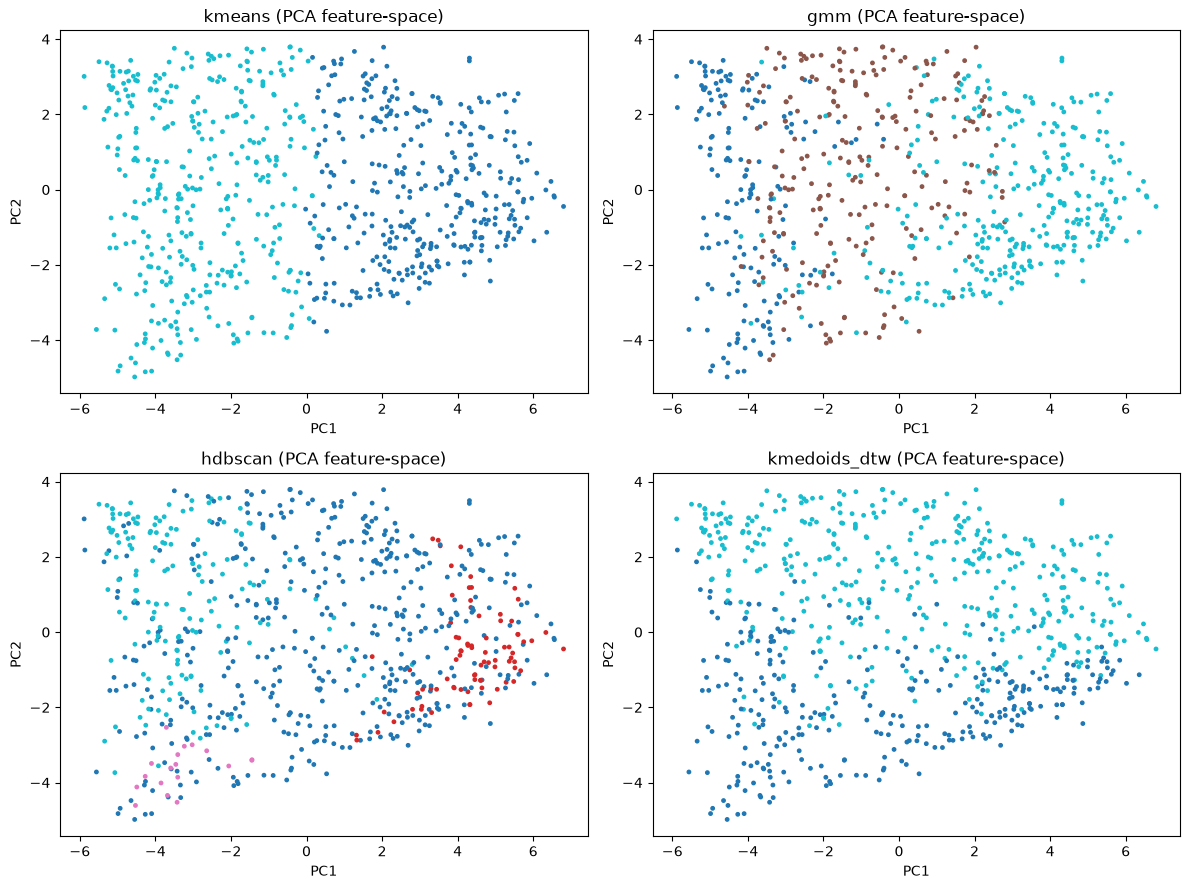

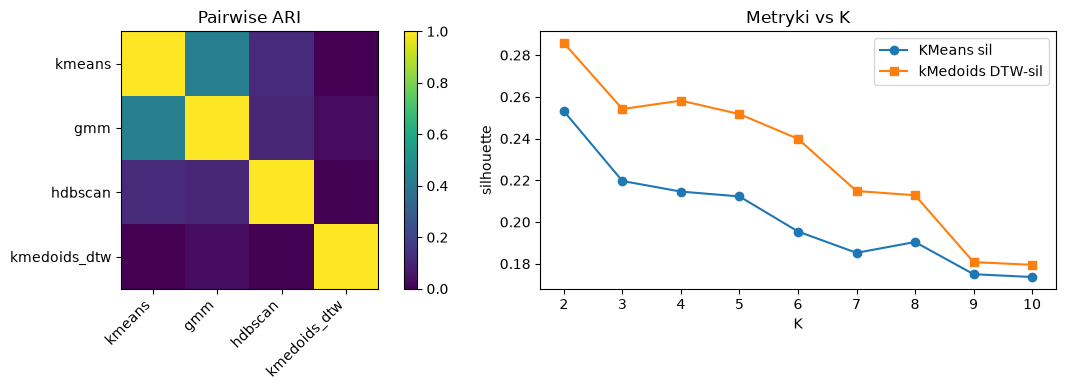

In [16]:
pca=PCA(2,random_state=RANDOM_STATE).fit(Xs_tr); P=pca.transform(Xs_tr)
fig,ax=plt.subplots(2,2,figsize=(12,9))
for a,mth in zip(ax.ravel(),methods):
    lab=np.array(labels_tr[mth]); sc=a.scatter(P[:,0],P[:,1],c=lab,s=6,cmap="tab10")
    a.set_title(f"{mth} (PCA feature-space)"); a.set_xlabel("PC1"); a.set_ylabel("PC2")
fig.tight_layout(); fig.savefig(NB3/"figures/pca_clusters.png",dpi=120); plt.show()

fig,ax=plt.subplots(1,2,figsize=(12,4))
im=ax[0].imshow(ARI.values.astype(float),vmin=0,vmax=1,cmap="viridis")
ax[0].set_xticks(range(len(methods))); ax[0].set_xticklabels(methods,rotation=45,ha="right")
ax[0].set_yticks(range(len(methods))); ax[0].set_yticklabels(methods); ax[0].set_title("Pairwise ARI"); fig.colorbar(im,ax=ax[0])
xs=list(K_RANGE); ax[1].plot(km_sel.K,km_sel.silhouette,"o-",label="KMeans sil")
ax[1].plot(kmed_sel.K,kmed_sel.DTW_silhouette,"s-",label="kMedoids DTW-sil")
ax[1].set_xlabel("K"); ax[1].set_ylabel("silhouette"); ax[1].legend(); ax[1].set_title("Metryki vs K")
fig.tight_layout(); fig.savefig(NB3/"figures/agreement_and_K.png",dpi=120); plt.show()

## 12. Finalna tabela porównawcza (wielokryterialna, bez jednego „overall score")

In [17]:
def native_str(m):
    return "; ".join(f"{k}={v}" for k,v in native[m].items())
comp=pd.DataFrame([{
    "Method":m,
    "K":STRUCT[m]["n_clusters"],
    "FeatureSilhouette":round(FEATURE_SIL[m],3) if FEATURE_SIL[m]==FEATURE_SIL[m] else np.nan,
    "StabilityARI":round(STAB[m][0],3),
    "StabilityNMI":round(STAB[m][2],3),
    "OpHomogeneity":round(HOMOG[m],3),
    "Noise%":round(STRUCT[m]["noise_ratio"]*100,1),
    "LargestShare":STRUCT[m]["largest_share"],
    "NativeMetric":native_str(m),
    "FitTime_s":round(RUNTIMES.get(f"{m}_fit",np.nan),2),
} for m in methods])
pd.set_option("display.max_colwidth",60)
print(comp.to_string(index=False))

      Method  K  FeatureSilhouette  StabilityARI  StabilityNMI  OpHomogeneity  Noise%  LargestShare                                                          NativeMetric  FitTime_s
      kmeans  2              0.253         0.981         0.963          1.441     0.0         0.516                                                       inertia=16525.0       0.01
         gmm  3              0.146         0.494         0.445          1.443     0.0         0.447                            BIC=22341.4; AIC=15061.9; confidence=0.999       0.08
     hdbscan  3              0.348         0.740         0.665          1.056    64.4         0.221 DBCV=0.083; noise_ratio=0.644; coverage=0.356; mean_persistence=0.063       0.05
kmedoids_dtw  2              0.108         0.724         0.691          1.201     0.0         0.576                           DTW_silhouette=0.286; mean_intra_DTW=32.275       0.05


## 13. Eksport artefaktów dla NB#4

In [18]:
labels=pd.DataFrame({"segment_id":seg.segment_id,"profile_id":seg.profile_id,"in_train":seg.in_train})
for m in methods:
    full=np.empty(len(seg),dtype=int); full[TRAIN]=labels_tr[m]; full[TEST]=labels_te[m]
    labels[f"label_{m}"]=full
labels.to_csv(NB3/"cluster_labels.csv",index=False)
comp.to_csv(NB3/"clustering_comparison.csv",index=False)
ARI.to_csv(NB3/"pairwise_ARI.csv"); NMI.to_csv(NB3/"pairwise_NMI.csv")
km_sel.to_csv(NB3/"kmeans_selection.csv",index=False); gmm_sel.to_csv(NB3/"gmm_selection.csv",index=False)
hdb_sel.to_csv(NB3/"hdbscan_sensitivity.csv",index=False); kmed_sel.to_csv(NB3/"kmedoids_selection.csv",index=False)
np.save(NB3/"kmedoids_medoid_global_rows.npy",MEDOID_ROWS)
import joblib
joblib.dump({"kmeans":km,"gmm":gm,"hdbscan":hb},NB3/"cluster_models.joblib")
joblib.dump(scaler,NB3/"feature_scaler.joblib")
json.dump({"features_final":FEATS,"features_removed_nzv":nzv,"features_removed_corr":drop_corr,
           "K_kmeans":K_KM,"gmm_cov":COV_GMM,"K_gmm":K_GMM,"hdbscan_min_cluster_size":MCS,
           "hdbscan_min_samples":MS,"K_kmedoids":K_MED,"DTW_radius":DTW_RADIUS,"DTW_len":int(lvl.shape[1]),
           "random_state":RANDOM_STATE,"train_ids":cfg["train_ids"],"test_ids":cfg["test_ids"],
           "runtimes":{k:round(v,3) for k,v in RUNTIMES.items()}},
          open(NB3/"clustering_config.json","w"),indent=2)
print("Zapisano do",NB3.resolve()); print(sorted(p.name for p in NB3.glob('*')))

Zapisano do /Users/larysasagan/Desktop/ML Projekt/clustering_outputs
['cluster_labels.csv', 'cluster_models.joblib', 'clustering_comparison.csv', 'clustering_config.json', 'dtw_matrix_train.npy', 'feature_scaler.joblib', 'figures', 'gmm_selection.csv', 'hdbscan_sensitivity.csv', 'kmeans_selection.csv', 'kmedoids_medoid_global_rows.npy', 'kmedoids_selection.csv', 'pairwise_ARI.csv', 'pairwise_NMI.csv']


## 14. Wnioski metodologiczne i ograniczenia

### 1) Wyniki wynikające bezpośrednio z metryk
*(uzupełnić po uruchomieniu — odczyt z tabeli w sekcji 12)*: która metoda ma najwyższe Feature-Silhouette, najwyższą StabilityARI, najniższą OpHomogeneity, jaki noise% ma HDBSCAN, jak wypada DTW-Silhouette k-Medoids.

### 2) Interpretacja domenowa
Charakterystyki klastrów (sekcja 10) w jednostkach fizycznych: identyfikacja reżimów (bieg jałowy, wysoki moment, field weakening `i_d<0`, rekuperacja `torque<0`). Nazwy nadajemy tylko przy wystarczających przesłankach fizycznych. `pm_ext` to wyłącznie diagnostyka post-hoc.

### 3) Ograniczenia porównania feature-based vs trajectory-based
- Feature-Silhouette liczone w przestrzeni cech faworyzuje metody feature-based; dla k-Medoids raportujemy dodatkowo DTW-Silhouette (inna przestrzeń — nie porównywać wprost).
- DTW działa na segmentach przepróbkowanych do L=128 (kontrolowany kompromis; pełna zmienna długość byłaby O(L²) niewykonalna — patrz benchmark w sekcji 4).
- HDBSCAN w wysokiej wymiarowości bywa wrażliwy; główny wariant na cechach, PCA jako ewentualna redukcja.

### 4) Rekomendacje dla NB#4 (augmentacja)
- Do cluster-aware augmentation preferować metodę o wysokiej **stabilności** i **homogeniczności operacyjnej** oraz akceptowalnym noise/coverage — nie samą separację.
- Rzadkie reżimy (rekuperacja) augmentować ostrożnie; zachować relacje fizyczne (i_q↔torque, i_d↔speed); `pm`/temperatury odtwarzać z historii, nie perturbować.
- Ostateczny wybór metody rozstrzygnąć w NB#5 wg wpływu na RMSE/MAE/R² regresji `pm`.

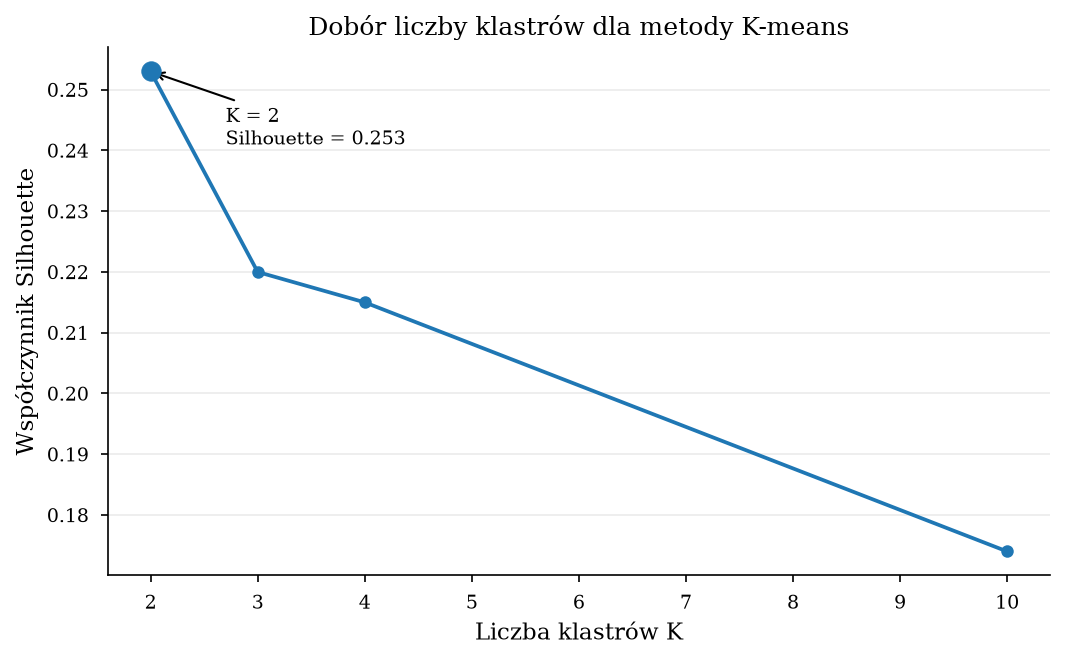

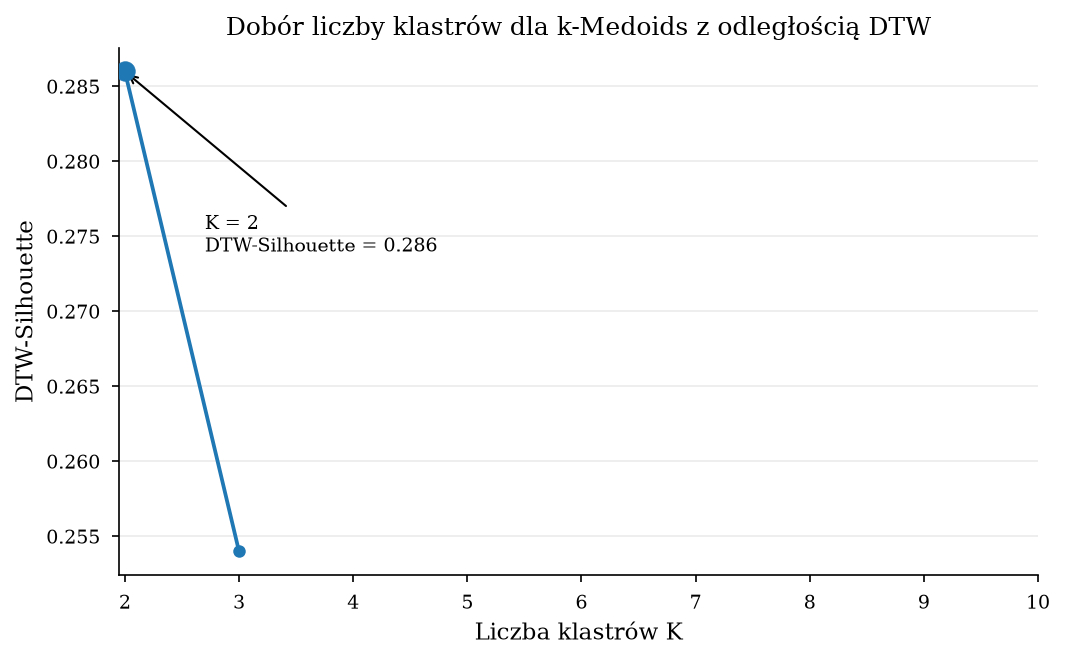

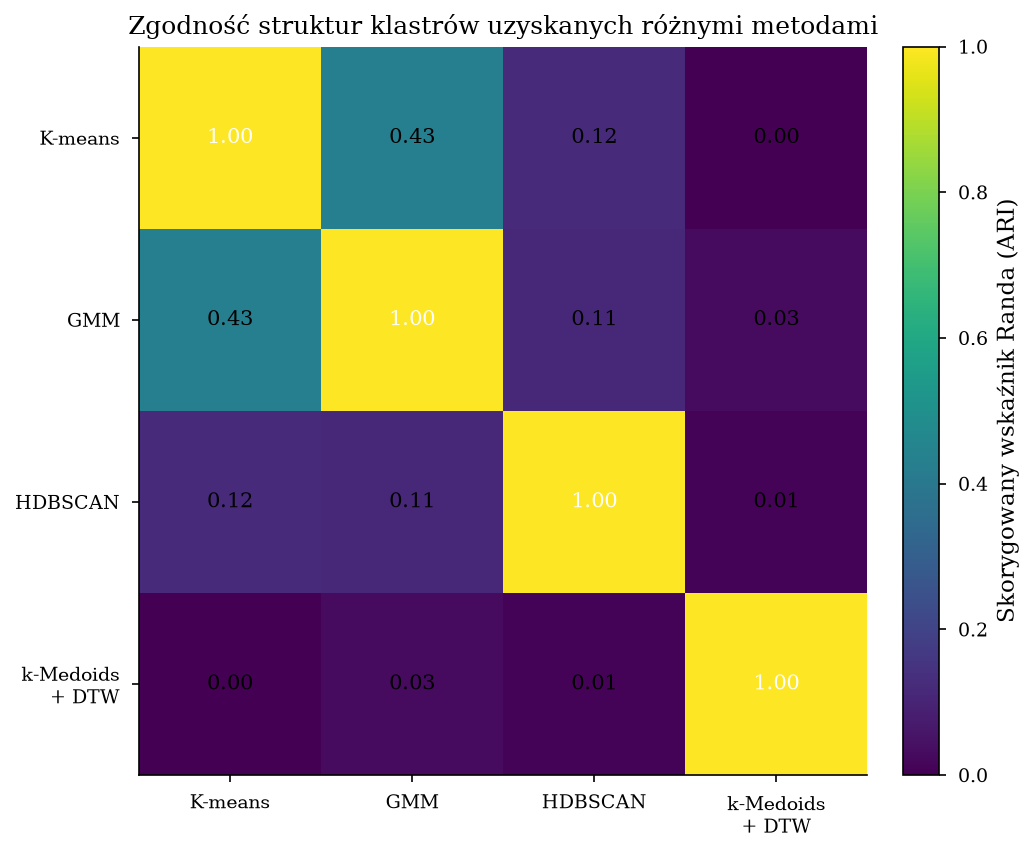

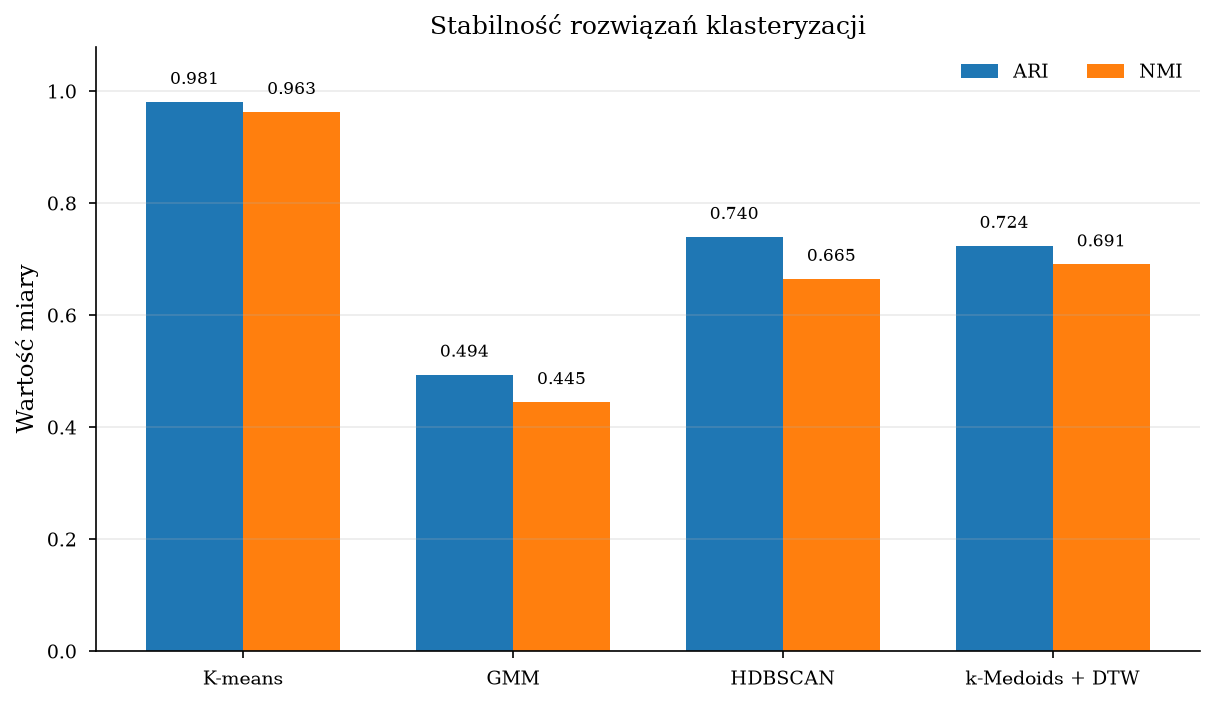

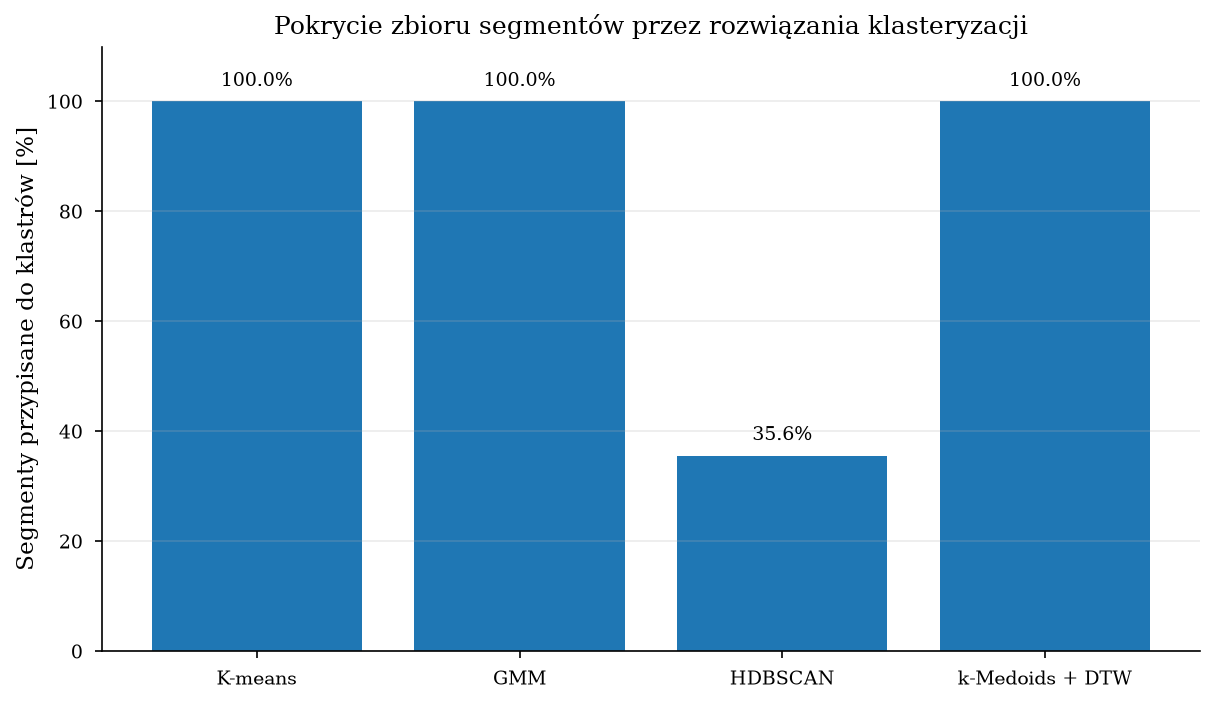

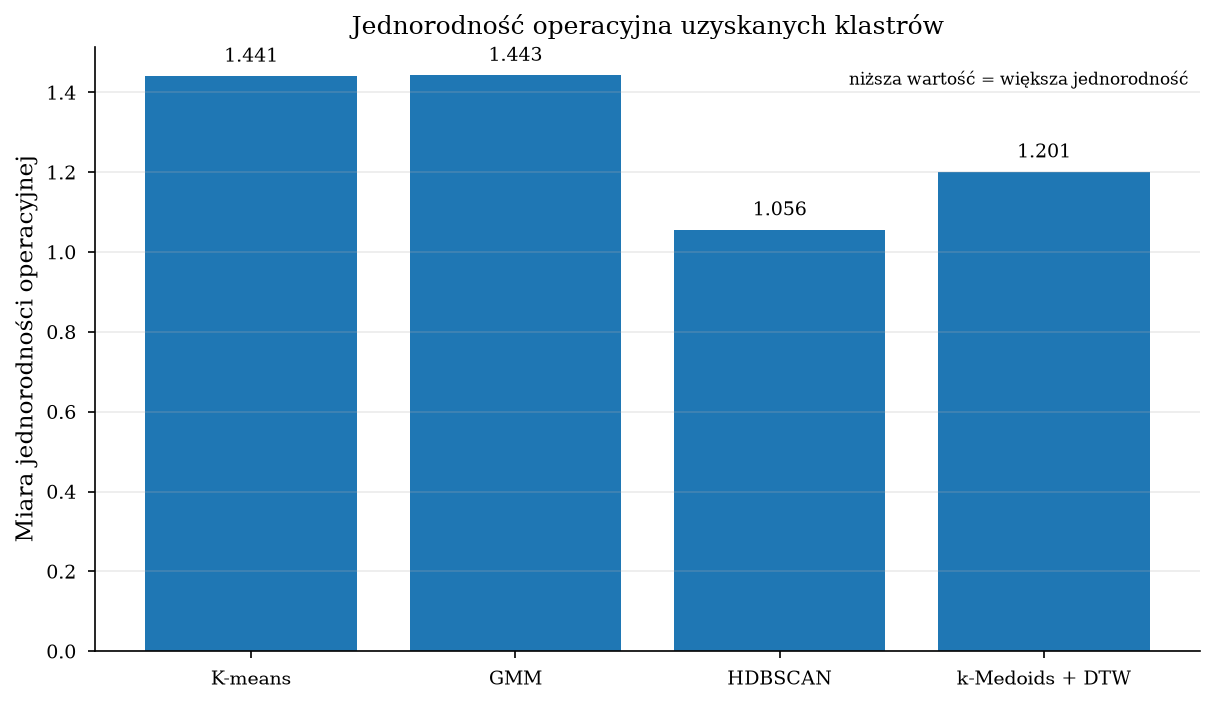


Pominięto wykresy PCA.
W środowisku nie znaleziono Xs lub etykiet klastrów.
Podłącz zmienne z finalnego notebooka:
  Xs
  labels_kmeans
  labels_gmm
  labels_hdbscan
  labels_dtw

Tabela porównawcza:

         Metoda  K  Silhouette  Stability ARI  Stability NMI  Jednorodność operacyjna  Szum [%]  Pokrycie [%]
        K-means  2       0.253          0.981          0.963                    1.441       0.0         100.0
            GMM  3       0.146          0.494          0.445                    1.443       0.0         100.0
        HDBSCAN  3       0.348          0.740          0.665                    1.056      64.4          35.6
k-Medoids + DTW  2       0.108          0.724          0.691                    1.201       0.0         100.0

Wyniki zapisano w katalogu: /Users/larysasagan/Desktop/ML Projekt/figures_chapter_6


In [1]:
# ============================================================
# WIZUALIZACJA WYNIKÓW KLASTERYZACJI — ROZDZIAŁ 6
#
# Generowane ryciny:
# 1. Dobór liczby klastrów K — K-means
# 2. Dobór liczby klastrów K — k-Medoids + DTW
# 3. Zgodność metod — macierz Pairwise ARI
# 4. Porównanie stabilności metod
# 5. Pokrycie danych / udział szumu
# 6. PCA — porównanie struktur klastrów (opcjonalnie)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# ============================================================
# 1. KONFIGURACJA
# ============================================================

OUTPUT_DIR = Path("figures_chapter_6")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})


def save_figure(fig, filename):
    """
    Zapisuje rycinę w formacie PNG oraz PDF.
    """
    fig.savefig(
        OUTPUT_DIR / f"{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        OUTPUT_DIR / f"{filename}.pdf",
        bbox_inches="tight"
    )


# ============================================================
# 2. DANE Z EKSPERYMENTU
# ============================================================

# ------------------------------------------------------------
# K-means — Silhouette dla kolejnych wartości K
# ------------------------------------------------------------

k_values = np.arange(2, 11)

kmeans_silhouette = np.array([
    0.253,
    0.220,
    0.215,
    # WSTAW TUTAJ dokładne wartości K=5...10 z notebooka
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    0.174
])


# ------------------------------------------------------------
# k-Medoids + DTW
# ------------------------------------------------------------

dtw_silhouette = np.array([
    0.286,
    0.254,
    # WSTAW TUTAJ dokładne wartości K=4...10 z notebooka
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan
])


# ------------------------------------------------------------
# Wyniki finalnych modeli
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Metoda": [
        "K-means",
        "GMM",
        "HDBSCAN",
        "k-Medoids + DTW"
    ],
    "K": [
        2,
        3,
        3,
        2
    ],
    "Silhouette_feature": [
        0.253,
        0.146,
        0.348,
        0.108
    ],
    "Stability_ARI": [
        0.981,
        0.494,
        0.740,
        0.724
    ],
    "Stability_NMI": [
        0.963,
        0.445,
        0.665,
        0.691
    ],
    "OpHomogeneity": [
        1.441,
        1.443,
        1.056,
        1.201
    ],
    "Noise_pct": [
        0.0,
        0.0,
        64.4,
        0.0
    ],
})

comparison["Coverage_pct"] = 100 - comparison["Noise_pct"]


# ------------------------------------------------------------
# Pairwise ARI
#
# Jeśli masz dokładne pairwise_ARI.csv,
# lepiej wczytać je zamiast wartości zaokrąglonych.
# ------------------------------------------------------------

method_labels = [
    "K-means",
    "GMM",
    "HDBSCAN",
    "k-Medoids\n+ DTW"
]

ari_matrix = np.array([
    [1.00, 0.43, 0.12, 0.00],
    [0.43, 1.00, 0.11, 0.03],
    [0.12, 0.11, 1.00, 0.01],
    [0.00, 0.03, 0.01, 1.00]
])


# ============================================================
# RYCINA 6.1A
# DOBÓR K — K-MEANS
# ============================================================

fig, ax = plt.subplots(figsize=(7.2, 4.5))

valid = ~np.isnan(kmeans_silhouette)

ax.plot(
    k_values[valid],
    kmeans_silhouette[valid],
    marker="o",
    linewidth=1.8,
    markersize=6
)

# zaznaczenie optimum
best_idx = np.nanargmax(kmeans_silhouette)
best_k = k_values[best_idx]
best_value = kmeans_silhouette[best_idx]

ax.scatter(
    best_k,
    best_value,
    s=90,
    zorder=5
)

ax.annotate(
    f"K = {best_k}\nSilhouette = {best_value:.3f}",
    xy=(best_k, best_value),
    xytext=(best_k + 0.7, best_value - 0.012),
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    ),
    fontsize=9
)

ax.set_xlabel("Liczba klastrów K")
ax.set_ylabel("Współczynnik Silhouette")

ax.set_title(
    "Dobór liczby klastrów dla metody K-means"
)

ax.set_xticks(k_values)
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

save_figure(
    fig,
    "06_01a_kmeans_silhouette"
)

plt.show()


# ============================================================
# RYCINA 6.1B
# DOBÓR K — k-MEDOIDS + DTW
# ============================================================

fig, ax = plt.subplots(figsize=(7.2, 4.5))

valid = ~np.isnan(dtw_silhouette)

ax.plot(
    k_values[valid],
    dtw_silhouette[valid],
    marker="o",
    linewidth=1.8,
    markersize=6
)

best_idx = np.nanargmax(dtw_silhouette)
best_k = k_values[best_idx]
best_value = dtw_silhouette[best_idx]

ax.scatter(
    best_k,
    best_value,
    s=90,
    zorder=5
)

ax.annotate(
    f"K = {best_k}\nDTW-Silhouette = {best_value:.3f}",
    xy=(best_k, best_value),
    xytext=(best_k + 0.7, best_value - 0.012),
    arrowprops=dict(
        arrowstyle="->",
        lw=1
    ),
    fontsize=9
)

ax.set_xlabel("Liczba klastrów K")
ax.set_ylabel("DTW-Silhouette")

ax.set_title(
    "Dobór liczby klastrów dla k-Medoids z odległością DTW"
)

ax.set_xticks(k_values)
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

save_figure(
    fig,
    "06_01b_kmedoids_dtw_silhouette"
)

plt.show()


# ============================================================
# RYCINA 6.2
# MACIERZ ZGODNOŚCI PAIRWISE ARI
# ============================================================

fig, ax = plt.subplots(figsize=(7.0, 5.8))

im = ax.imshow(
    ari_matrix,
    vmin=0,
    vmax=1,
    aspect="equal"
)

ax.set_xticks(np.arange(len(method_labels)))
ax.set_yticks(np.arange(len(method_labels)))

ax.set_xticklabels(method_labels)
ax.set_yticklabels(method_labels)

# wartości w komórkach
for i in range(ari_matrix.shape[0]):
    for j in range(ari_matrix.shape[1]):

        value = ari_matrix[i, j]

        # automatyczny kontrast napisu
        text_color = (
            "white"
            if value > 0.55
            else "black"
        )

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            color=text_color
        )

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "Skorygowany wskaźnik Randa (ARI)"
)

ax.set_title(
    "Zgodność struktur klastrów uzyskanych różnymi metodami"
)

fig.tight_layout()

save_figure(
    fig,
    "06_02_pairwise_ari"
)

plt.show()


# ============================================================
# RYCINA 6.3
# STABILNOŚĆ ROZWIĄZAŃ
# ============================================================

fig, ax = plt.subplots(figsize=(8.2, 4.8))

x = np.arange(len(comparison))
width = 0.36

bars_ari = ax.bar(
    x - width / 2,
    comparison["Stability_ARI"],
    width,
    label="ARI"
)

bars_nmi = ax.bar(
    x + width / 2,
    comparison["Stability_NMI"],
    width,
    label="NMI"
)

ax.set_xticks(x)
ax.set_xticklabels(comparison["Metoda"])

ax.set_ylabel("Wartość miary")
ax.set_ylim(0, 1.08)

ax.set_title(
    "Stabilność rozwiązań klasteryzacji"
)

ax.legend(
    frameon=False,
    ncol=2
)

ax.grid(
    axis="y",
    alpha=0.25
)


# wartości nad słupkami
for bars in [bars_ari, bars_nmi]:

    for bar in bars:

        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.025,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )


fig.tight_layout()

save_figure(
    fig,
    "06_03_cluster_stability"
)

plt.show()


# ============================================================
# RYCINA 6.4
# POKRYCIE DANYCH PRZEZ KLASTRY
# ============================================================

fig, ax = plt.subplots(figsize=(8.2, 4.8))

bars = ax.bar(
    comparison["Metoda"],
    comparison["Coverage_pct"]
)

ax.set_ylabel("Segmenty przypisane do klastrów [%]")
ax.set_ylim(0, 110)

ax.set_title(
    "Pokrycie zbioru segmentów przez rozwiązania klasteryzacji"
)

ax.grid(
    axis="y",
    alpha=0.25
)

for bar, value in zip(
    bars,
    comparison["Coverage_pct"]
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

fig.tight_layout()

save_figure(
    fig,
    "06_04_cluster_coverage"
)

plt.show()


# ============================================================
# RYCINA 6.5
# JEDNORODNOŚĆ OPERACYJNA
#
# UWAGA:
# niższa wartość = większa jednorodność
# ============================================================

fig, ax = plt.subplots(figsize=(8.2, 4.8))

bars = ax.bar(
    comparison["Metoda"],
    comparison["OpHomogeneity"]
)

ax.set_ylabel("Miara jednorodności operacyjnej")
ax.set_title(
    "Jednorodność operacyjna uzyskanych klastrów"
)

ax.grid(
    axis="y",
    alpha=0.25
)

for bar, value in zip(
    bars,
    comparison["OpHomogeneity"]
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.025,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# informacja interpretacyjna
ax.text(
    0.99,
    0.96,
    "niższa wartość = większa jednorodność",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=8
)

fig.tight_layout()

save_figure(
    fig,
    "06_05_operational_homogeneity"
)

plt.show()


# ============================================================
# RYCINA 6.6
# PCA — PORÓWNANIE STRUKTUR KLASTRÓW
#
# Ta część wymaga istniejących:
#
# Xs               -> zestandaryzowana macierz cech
# labels_kmeans
# labels_gmm
# labels_hdbscan
# labels_dtw
#
# Jeżeli zmienne mają inne nazwy w notebooku,
# zmień je poniżej.
# ============================================================

try:

    from sklearn.decomposition import PCA

    pca = PCA(
        n_components=2,
        random_state=42
    )

    X_pca = pca.fit_transform(Xs)

    clustering_results = {
        "K-means": labels_kmeans,
        "GMM": labels_gmm,
        "HDBSCAN": labels_hdbscan,
        "k-Medoids + DTW": labels_dtw
    }

    # --------------------------------------------------------
    # Każda metoda jako osobna rycina.
    # To jest lepsze do pracy niż 4 małe subploty.
    # --------------------------------------------------------

    for method_name, labels in clustering_results.items():

        fig, ax = plt.subplots(
            figsize=(7.0, 5.2)
        )

        unique_labels = np.unique(labels)

        for label in unique_labels:

            mask = labels == label

            label_name = (
                "Szum"
                if label == -1
                else f"Klaster {label}"
            )

            ax.scatter(
                X_pca[mask, 0],
                X_pca[mask, 1],
                s=18,
                alpha=0.65,
                label=label_name
            )

        explained = (
            pca.explained_variance_ratio_ * 100
        )

        ax.set_xlabel(
            f"PC1 ({explained[0]:.1f}% wariancji)"
        )

        ax.set_ylabel(
            f"PC2 ({explained[1]:.1f}% wariancji)"
        )

        ax.set_title(
            f"Projekcja PCA — {method_name}"
        )

        ax.legend(
            frameon=False,
            loc="best"
        )

        ax.grid(
            alpha=0.20
        )

        fig.tight_layout()

        safe_name = (
            method_name
            .lower()
            .replace(" ", "_")
            .replace("+", "plus")
        )

        save_figure(
            fig,
            f"06_06_pca_{safe_name}"
        )

        plt.show()


except NameError:

    print(
        "\nPominięto wykresy PCA."
        "\nW środowisku nie znaleziono Xs lub etykiet klastrów."
        "\nPodłącz zmienne z finalnego notebooka:"
        "\n  Xs"
        "\n  labels_kmeans"
        "\n  labels_gmm"
        "\n  labels_hdbscan"
        "\n  labels_dtw"
    )


# ============================================================
# 7. TABELA DO EKSPORTU
# ============================================================

table_export = comparison.copy()

table_export = table_export.rename(columns={
    "Silhouette_feature": "Silhouette",
    "Stability_ARI": "Stability ARI",
    "Stability_NMI": "Stability NMI",
    "OpHomogeneity": "Jednorodność operacyjna",
    "Noise_pct": "Szum [%]",
    "Coverage_pct": "Pokrycie [%]"
})

print("\nTabela porównawcza:\n")

print(
    table_export.round(3).to_string(index=False)
)

table_export.to_csv(
    OUTPUT_DIR / "tabela_porownanie_metod.csv",
    index=False
)

print(
    f"\nWyniki zapisano w katalogu: {OUTPUT_DIR.resolve()}"
)